In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the dataset
data = pd.read_csv("car data.csv")

In [3]:
# Display the first few rows
print("Dataset Sample:")
print(data.head())

Dataset Sample:
   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  pe

In [4]:
# Clean up the data
data = data.dropna(subset=['price'])  # Remove rows with missing target values
data = data.select_dtypes(include=[np.number])  # Keep only numeric columns

In [5]:
# Separate features (X) and target (y)
X = data.drop(['price'], axis=1)
y = data['price']

In [6]:
# Add a column of ones to X for the intercept
X = np.c_[np.ones(X.shape[0]), X]

In [7]:
# Convert y to numpy array
y = y.values.reshape(-1, 1)

In [8]:
# Split the data manually (80% train, 20% test)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [9]:
# Linear Regression using Normal Equation: θ = (XᵀX)⁻¹ Xᵀy
theta = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train

In [10]:
# Predictions
y_pred = X_test @ theta

In [11]:
# Evaluation metrics
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)
r2 = 1 - np.sum((y_test - y_pred) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2)

print(f"Model Coefficients: {theta.flatten()}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Model Coefficients: [-5.57340758e+04 -2.25088360e+01  6.81294889e+02  1.75415769e+02
 -3.60831464e+01  1.81625696e+02  2.71637670e+02  1.77376090e+00
  1.19617240e+02  1.06306470e+03 -3.67445896e+03  2.95499043e+02
  3.62652760e+01  2.66040167e+00 -2.56307858e+02  2.51708362e+02]
RMSE: 3209.71
R² Score: 0.43


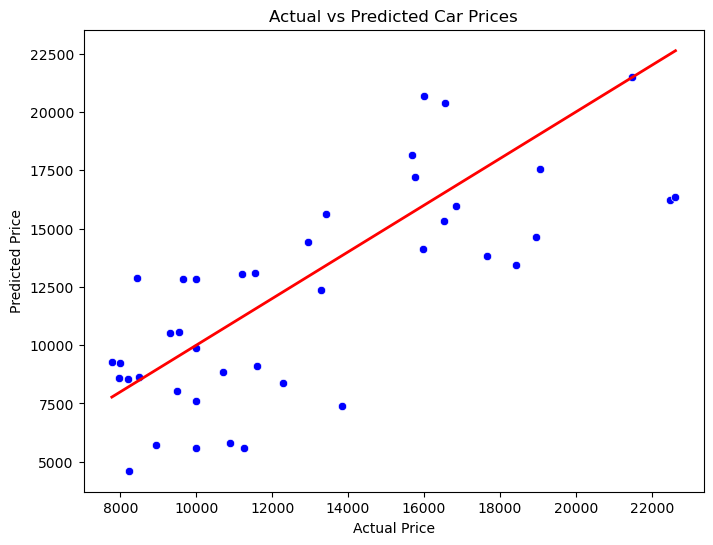

In [12]:
# Plot actual vs predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test.flatten(), y=y_pred.flatten(), color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.title('Actual vs Predicted Car Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()